In [1]:
# Imports and Setup and Parameters
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
import random
from tqdm.auto import tqdm


# Add 'lang_complexity' to python path
sys.path.append(os.path.abspath('lang_complexity'))

from lang_complexity.complexity import complexities

# Jupyter magic command to display plots inline
%matplotlib inline

# List of Compleity Metric for Variance Analysis
SELECTED_METRICS = [
    "morphology_deletion_bzip2", 
    "morphology_deletion_gzip", 
    "morphology_replacement_bzip2", 
    "morphology_replacement_gzip", 
    "syntactic_deletion_bzip2", 
    "syntactic_deletion_gzip"]

REPRODUCIBILITY_SEED = 42

# Data Preparation and Base Experiments


In [2]:
# Load Dataset from memory
df = pd.read_csv('data/working_sample.csv', index_col=0)
df.head()

,register,carolina_typology,domain,text
index,,,,
4247009,Activities / Experiences Sharing,#WIKIS,Virtual,Começará no dia 29 de junho e terminará em 24 ...
1793632,Activities / Experiences Sharing,#WIKIS,Virtual,"Carolina Rossini, Harvard University Dr."
4123755,Activities / Experiences Sharing,#WIKIS,Virtual,Uma coisa interessante é que concluímos que os...
4293608,Activities / Experiences Sharing,#WIKIS,Virtual,"Não há ""membros"" ou ""diretores"" do movimento, ..."
343738,Activities / Experiences Sharing,#WIKIS,Virtual,E isso nos impõe novos desafios.


In [3]:
# Variance Experiment Function
# It conducts experiments that will produce the data
# for the sentence-level analysis of variance.

def run_variance_experiments(df, m, n, selected_metrics, complexities, seed=REPRODUCIBILITY_SEED):
    """
    Runs variance experiments on a sampled DataFrame.

    For each 'register', this function runs 'm' experiments.
    Each experiment consists of:
    1. Sampling 'n' texts from that register.
    2. Shuffling the 'n' texts and their original indices.
    3. Concatenating the shuffled texts into a single string.
    4. Computing all metrics in 'selected_metrics' on that string.
    5. Storing the results, the register, and the list of shuffled indices.

    Args:
        df (pd.DataFrame): The input DataFrame (e.g., df_sampled).
                           Must contain 'register' and 'text' columns.
        m (int): The number of experiments to run *per register*.
        n (int): The number of samples to combine in *each experiment*.
        selected_metrics (list): A list of complexity metric name strings.
        complexities (dict): A dict mapping metric names to objects with a
                             .compute(text) method.
        seed (int): A master seed for reproducibility.

    Returns:
        pd.DataFrame: The variance_experiments_df with all results.
    """
    
    # Set the seed for Python's built-in 'random' module (for shuffling)
    random.seed(seed)
    
    all_experiments_data = []
    
    # Get the unique register names
    registers = df['register'].unique()
    
    print(f"Starting variance experiments...")
    print(f"Parameters: m={m}, n={n}, seed={seed}")
    print(f"Metrics: {selected_metrics}")
    print(f"Total registers: {len(registers)}")
    print(f"Total experiments to run: {len(registers) * m}")

    # Use tqdm for a progress bar over the registers
    for j, register_name in enumerate(tqdm(registers, desc="Registers")):
        
        # Filter the DataFrame for the current register
        df_register = df[df['register'] == register_name]
        
        # Run 'm' experiments for this register
        for i in range(m):
            
            # --- Sample 'n' entries ---
            # We create a unique, deterministic seed for *each experiment*
            # This ensures .sample() is reproducible and doesn't just
            # pick the same 'n' entries 'm' times.
            current_seed = seed + (j * m) + i
            
            try:
                experiment_sample = df_register.sample(
                    n=n, 
                    random_state=current_seed,
                    replace=False # Ensure we sample unique sentences
                )
            except ValueError as e:
                print(f"Warning: Could not sample n={n} from register '{register_name}' "
                      f"(it has {len(df_register)} entries). Skipping experiment.")
                print(f"Error: {e}")
                continue # Skip this experiment
            
            # --- Get text and indices ---
            # Get the original DataFrame indices and the text
            texts = experiment_sample['text'].tolist()
            indices = experiment_sample.index.tolist()

            # --- Shuffle order ---
            # Zip texts and indices together to shuffle them in unison
            pairs = list(zip(texts, indices))
            random.shuffle(pairs)
            
            # Unzip into the new shuffled order
            shuffled_texts, shuffled_indices = zip(*pairs)
            
            # --- Concatenate ---
            # Join texts with a space.
            concatenated_text = " ".join(shuffled_texts)
            
            # --- Store experiment data ---
            # This dict will become one row in our final DataFrame
            experiment_data = {
                'register': register_name,
                # Store the list of indices in the order of concatenation
                'source_indices': list(shuffled_indices) 
            }

            # --- Compute metrics ---
            for metric in selected_metrics:
                try:
                    result = complexities[metric].compute(concatenated_text)
                    experiment_data[metric] = result
                except Exception as e:
                    print(f"Error computing metric '{metric}' for register '{register_name}'.")
                    print(f"Error: {e}")
                    experiment_data[metric] = None # Store None on failure
            
            # Add this experiment's results to our master list
            all_experiments_data.append(experiment_data)

    # --- Build final DataFrame ---
    print("\nAll experiments complete. Creating final DataFrame...")
    variance_experiments_df = pd.DataFrame(all_experiments_data)
    
    # Re-order columns for clarity 
    column_order = ['register', 'source_indices'] + selected_metrics
    
    print("Successfully created variance_experiments_df.")
    return variance_experiments_df


In [4]:
# 4. Run Variance Experiments
variance_experiments_df = run_variance_experiments(df=df,m=250,n=250, 
                                                   selected_metrics=SELECTED_METRICS,
                                                   complexities=complexities,
                                                   seed=REPRODUCIBILITY_SEED)
variance_experiments_df.to_csv("variance_experiments.csv", index=False)
variance_experiments_df.head()                                                   

Starting variance experiments...
Parameters: m=250, n=250, seed=42
Metrics: ['morphology_deletion_bzip2', 'morphology_deletion_gzip', 'morphology_replacement_bzip2', 'morphology_replacement_gzip', 'syntactic_deletion_bzip2', 'syntactic_deletion_gzip']
Total registers: 14
Total experiments to run: 3500


Registers:   0%|          | 0/14 [00:00<?, ?it/s]


All experiments complete. Creating final DataFrame...
Successfully created variance_experiments_df.


,register,source_indices,morphology_deletion_bzip2,morphology_deletion_gzip,morphology_replacement_bzip2,morphology_replacement_gzip,syntactic_deletion_bzip2,syntactic_deletion_gzip
0,Activities / Experiences Sharing,"[1578777, 970164, 1486389, 3928964, 4190203, 3...",-1.064871,-1.024428,1.716848,1.454273,0.941635,0.930841
1,Activities / Experiences Sharing,"[436366, 2199076, 4312243, 2177087, 3215037, 3...",-1.067118,-1.028731,1.704598,1.440210,0.945422,0.935882
2,Activities / Experiences Sharing,"[2424503, 518863, 1685078, 1569536, 1787164, 2...",-1.057687,-1.025067,1.728649,1.450219,0.937934,0.930313
3,Activities / Experiences Sharing,"[806566, 2063497, 1748370, 3055808, 3461439, 2...",-1.065492,-1.028912,1.686169,1.433052,0.941775,0.932375
4,Activities / Experiences Sharing,"[1417418, 3735461, 4150507, 4521587, 2503756, ...",-1.056618,-1.022024,1.703852,1.436073,0.940462,0.935119


# Visual Inspection of Results
## Violin Plots

Generating *sorted* vertical (stacked) violin plots for each metric...


/tmp/ipykernel_1010933/583671015.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


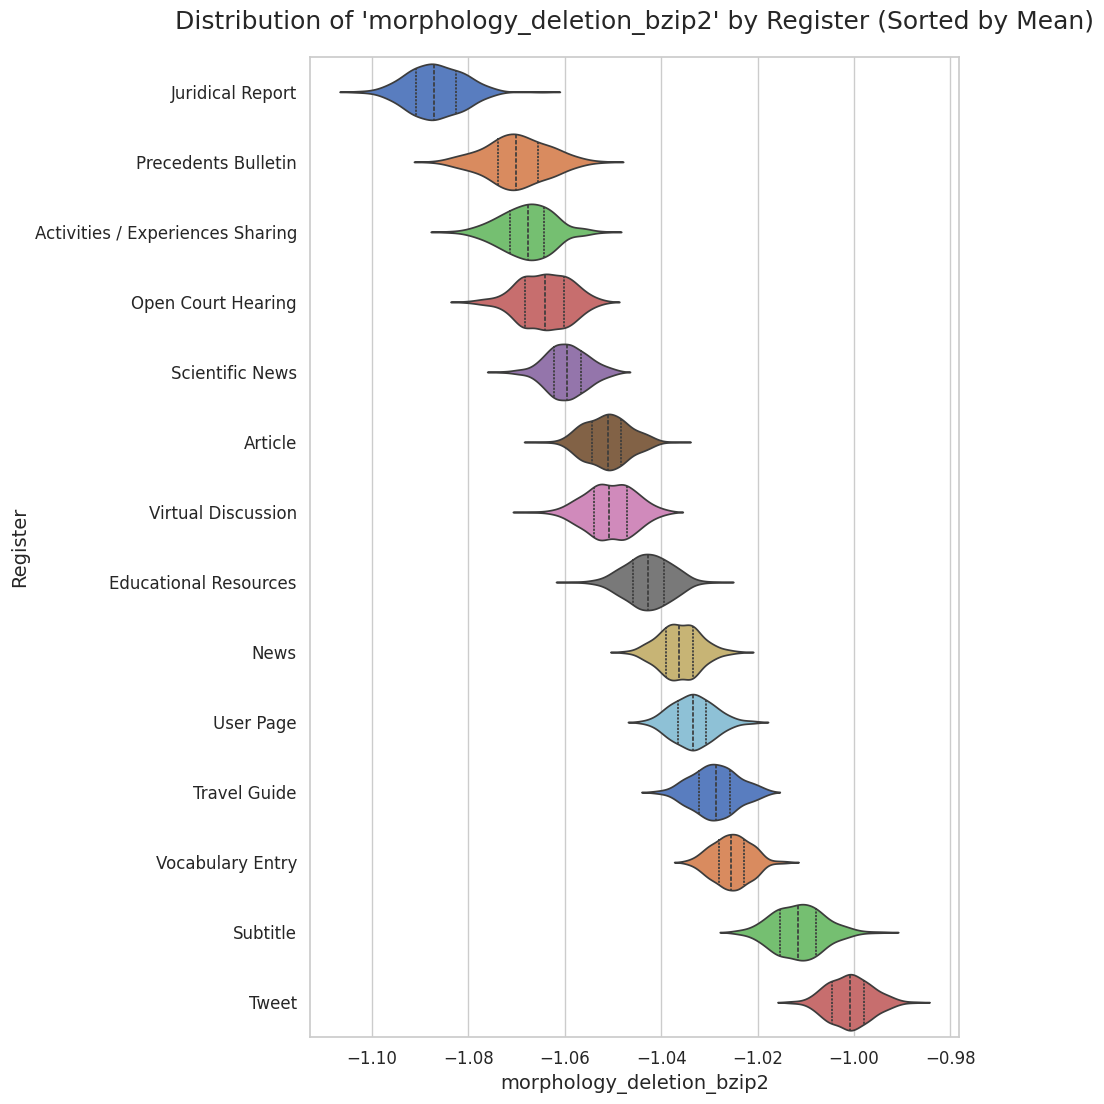

/tmp/ipykernel_1010933/583671015.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


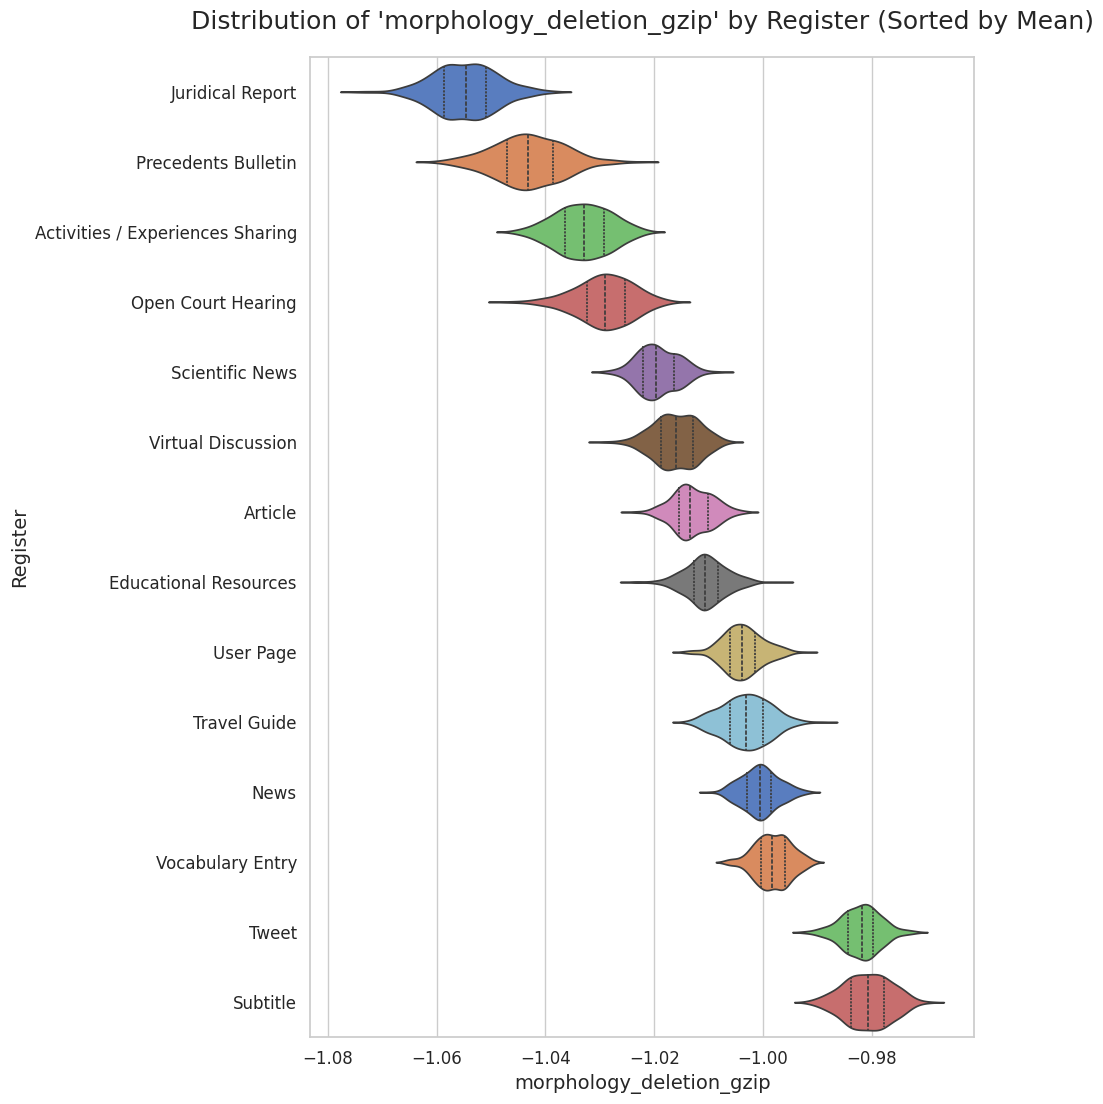

/tmp/ipykernel_1010933/583671015.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


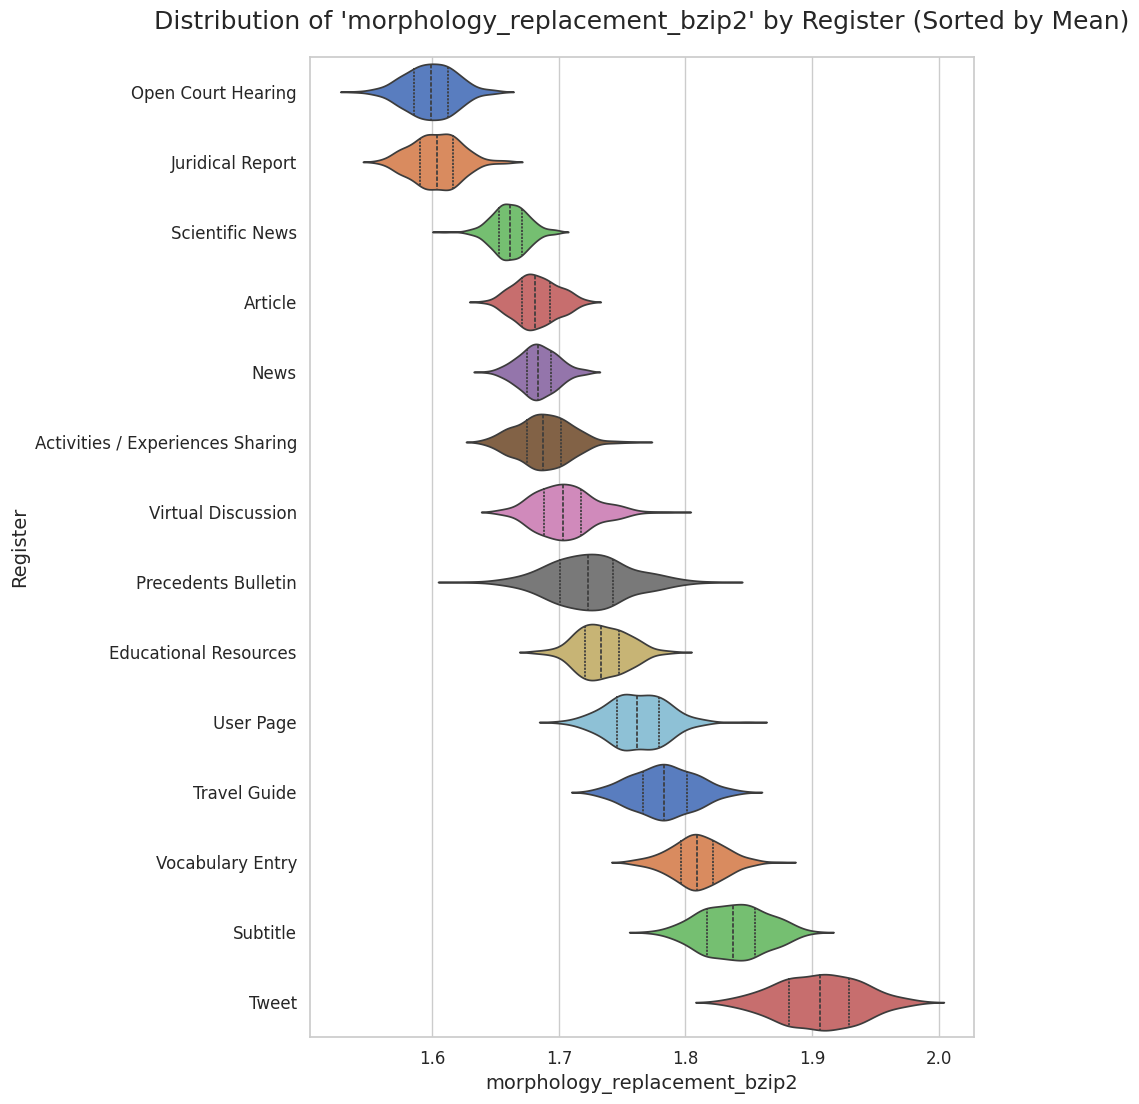

/tmp/ipykernel_1010933/583671015.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


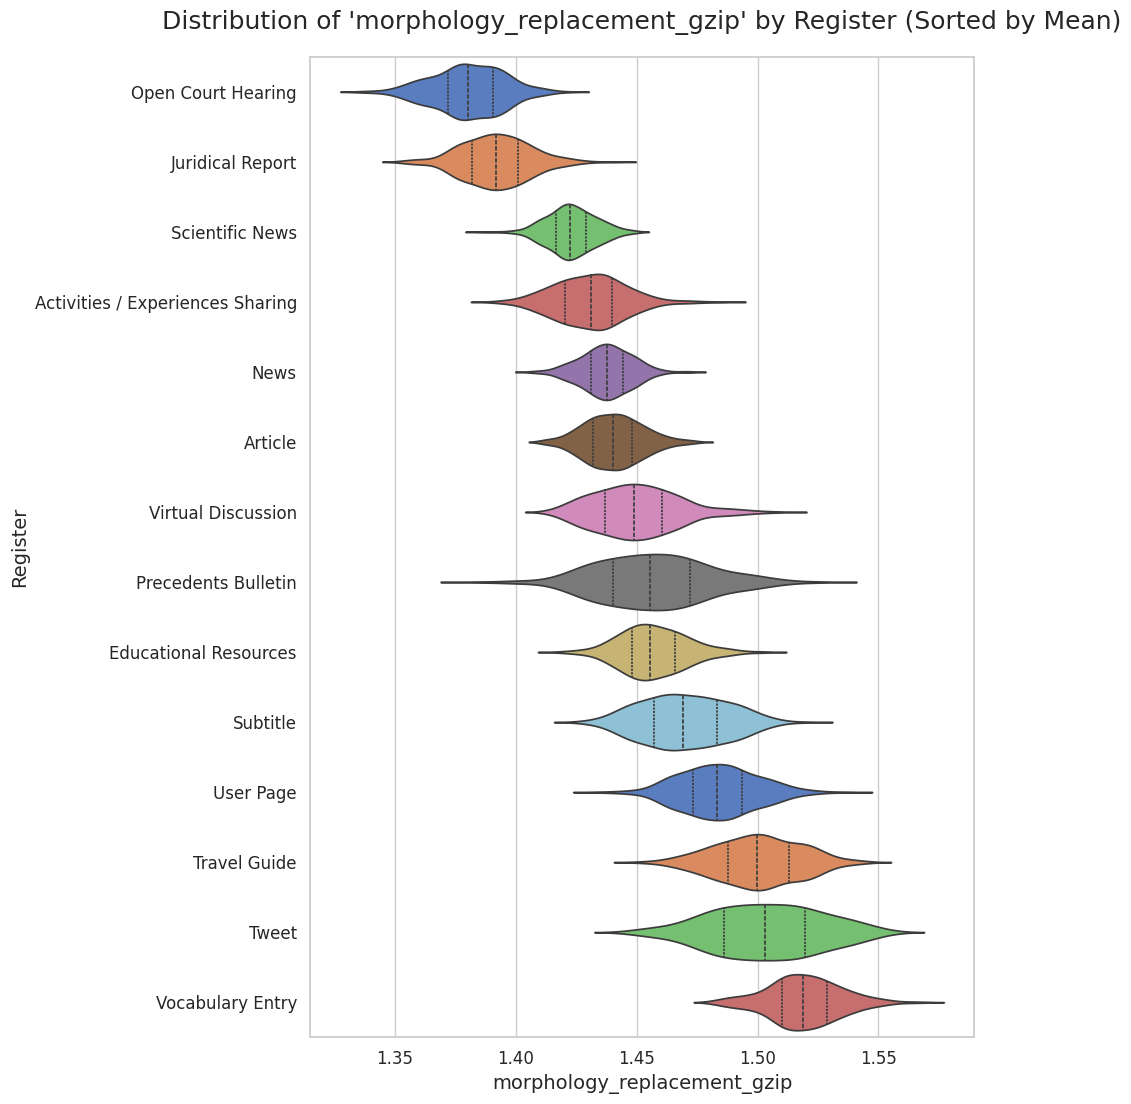

/tmp/ipykernel_1010933/583671015.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


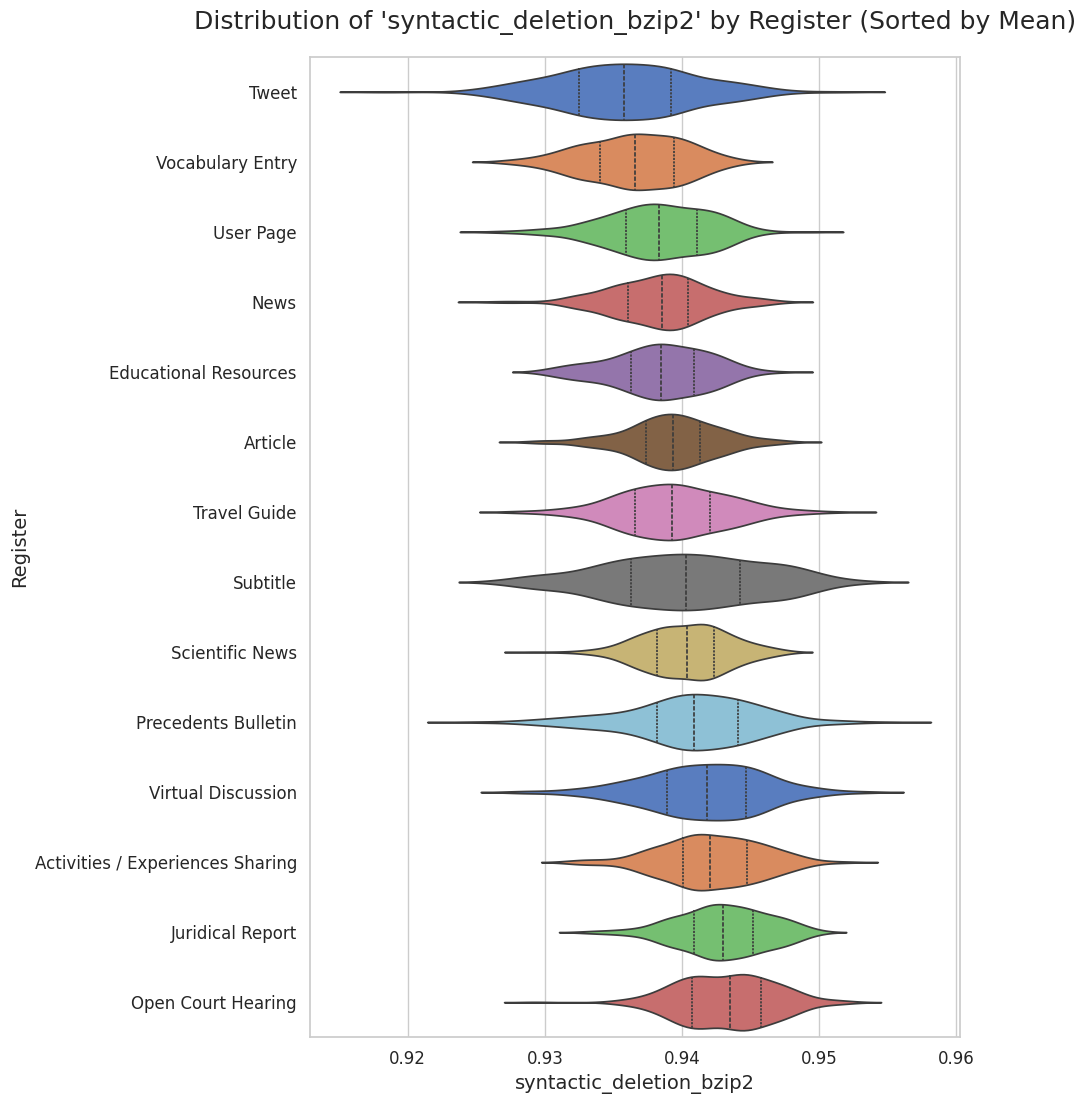

/tmp/ipykernel_1010933/583671015.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


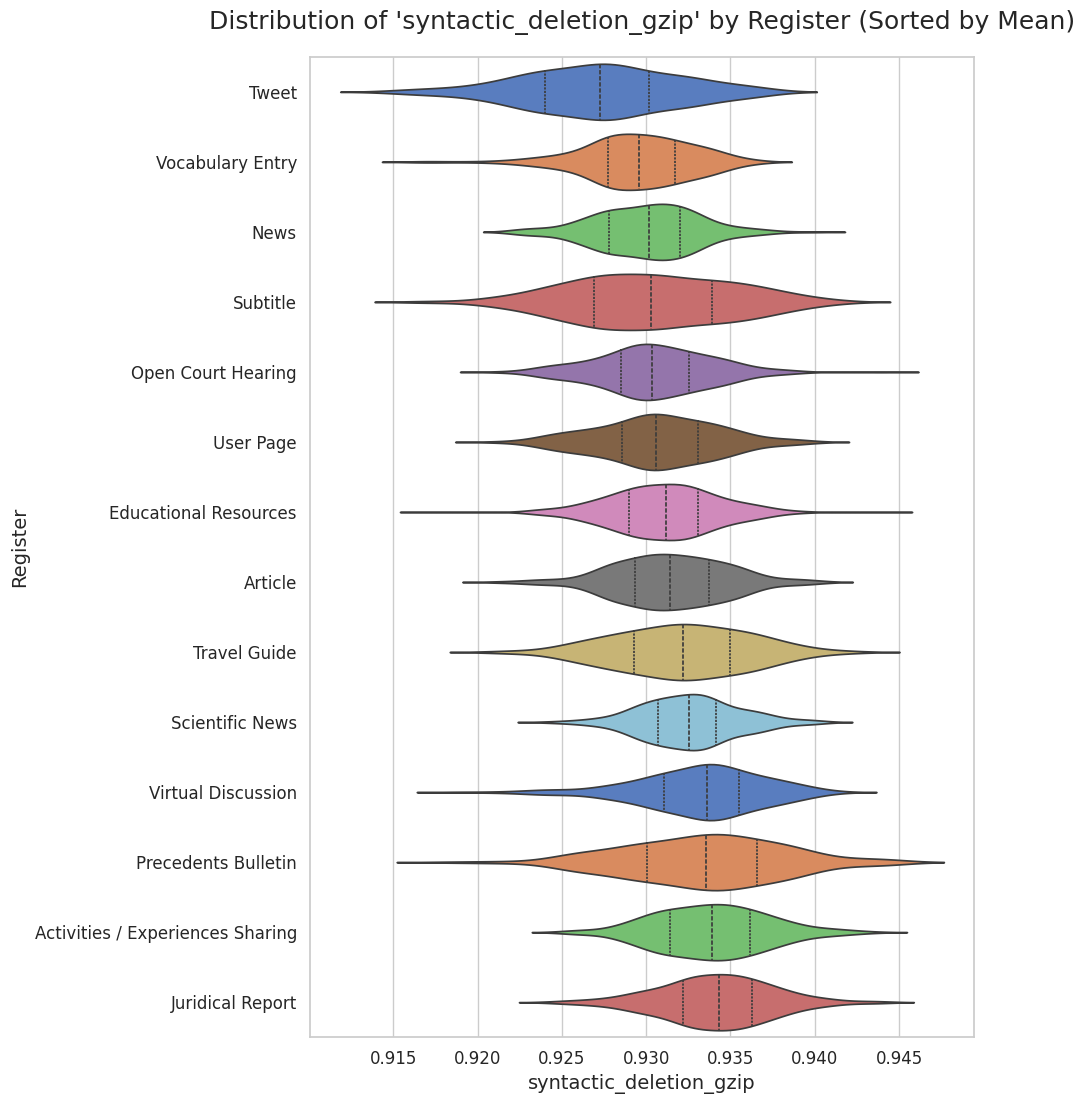

All sorted violin plots generated.


In [5]:
# Visual Inspection of experiment's results via violin plots for each metric

sns.set_theme(style="whitegrid")

print("Generating *sorted* vertical (stacked) violin plots for each metric...")

for metric in SELECTED_METRICS:
    
    # Calculate the mean of the current metric for each register
    mean_values = variance_experiments_df.groupby('register')[metric].mean()
    
    # Sort the registers based on their mean value (ascending by default)
    plot_order = mean_values.sort_values(ascending=True).index

    #Create a new figure
    num_registers = variance_experiments_df['register'].nunique()
    plt.figure(figsize=(10, max(8, num_registers * 0.8))) 
    
    # Create the violin plot (with the 'order' parameter)
    ax = sns.violinplot(
        data=variance_experiments_df,
        x=metric,
        y='register',
        order=plot_order,  # <-- This applies the sorting
        inner='quart',
        palette='muted'
    )
    
    # Set titles and labels
    ax.set_title(f"Distribution of '{metric}' by Register (Sorted by Mean)", fontsize=18, pad=20)
    ax.set_xlabel(metric, fontsize=14)
    ax.set_ylabel("Register", fontsize=14)
    
    # Adjust tick font sizes
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Adjust layout and display the plot
    plt.tight_layout() 
    plt.show()

print("All sorted violin plots generated.")